### Rolling Light

## Import libraries

In [1]:
#!pip install imblearn

In [2]:
import pandas as pd
import numpy as np

import glob
import os

import requests

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import zipfile

import xarray as xr

import folium
from folium.plugins import MarkerCluster

import pandas as pd
from geopy.geocoders import Nominatim

import geopandas as gpd
import cartopy.crs as ccrs

import imageio

from sklearn.neighbors import KDTree
from sklearn.neighbors import BallTree

from sklearn.preprocessing import RobustScaler

## Set parameters

In [3]:
decree_filename_base = 'arrete_'
decrees_folder_name = './../../data/raw/decrees'
communes_folder_name = './../../data/raw/opendatasoft'
weather_folder_name = './../../data/raw/weather/era5'
weather_ncfiles_folder_name = './../../data/raw/weather/era5/ncfiles2'
processed_data_folder_name = './../../data/processed'
output_data_folder_name = './../../data/processed/output'
decrees_filename = 'decrees.parquet'
decrees_locations_filename = 'decrees_locations.parquet'
communes_csv_filename = 'correspondance-code-insee-code-postal-202410.csv'
weather_filename = 'weather2.parquet'
weather_shema_filename = 'weather_shema2.csv'
weather_yearly_filename = 'weather2_yearly.parquet'
weather_yearly_shema_filename = 'weather_shema2_yearly.csv'
drought_filename = 'drought.parquet'
drought_shema_filename = 'drought_shema.csv'
drought_yearly_filename = 'drought_yearly.parquet'
drought_yearly_shema_filename = 'drought_yearly_shema.csv'
drought_commune_clean_filename = 'drought_commune_clean.parquet'
drought_commune_clean_shema_filename = 'drought_commune_clean_shema.csv'
drought_weather_filename = 'drought_weather.parquet'
drought_weather_shema_filename = 'drought_weather_shema.csv'
#weather_zip_file = "193fcd51a8958175843ecbbcaba057c8.zip"

## Load data

| Column    | Description                                      |
|-----------|--------------------------------------------------|
| date      | The date of the observation.                     |
| latitude  | The latitude coordinate of the observation point.|
| longitude | The longitude coordinate of the observation point.|
| number    | A unique identifier for the observation.         |
| expver    | Experiment version number.                       |
| u10       | 10-meter U-component of wind (eastward wind).    |
| v10       | 10-meter V-component of wind (northward wind).   |
| t2m       | 2-meter temperature (air temperature at 2 meters above the surface).|
| sp        | Surface pressure.                                |
| tp        | Total precipitation.                             |
| e         | Evaporation.                                     |
| sro       | Surface runoff.                                  |
| tcrw      | Total column water vapor.                        |
| stl1      | Soil temperature level 1.                        |
| stl2      | Soil temperature level 2.                        |
| slt       | Soil type.                                       |
| swvl1     | Volumetric soil water layer 1.                   |
| swvl2     | Volumetric soil water layer 2.                   |
| cvh       | High vegetation cover.                           |
| cvl       | Low vegetation cover.                            |
| tvh       | High vegetation type.                            |
| tvl       | Low vegetation type.                             |


## Import Data

In [4]:
# read the dataframe from parquet
import pandas as pd

df = pd.read_parquet(os.path.join(processed_data_folder_name, drought_weather_filename))




In [5]:
os.path.join(processed_data_folder_name, drought_weather_shema_filename)

'./../../data/processed/drought_weather_shema.csv'

In [6]:
# Load the schema (data types) from the file
schema = pd.read_csv(os.path.join(processed_data_folder_name, drought_weather_shema_filename), index_col=0).squeeze("columns")

In [7]:
# Apply the schema to the loaded dataframe
df = df.astype(schema.to_dict())

In [8]:
df_ori = df.copy()
# Remove rows where applied_1 is equal to 0
#df = df[df['applied_1'] != 0]



print(df)


      insee_1        nom_commune_1  latitude_1  longitude_1  year_1  \
0       10002           AILLEVILLE   48.255000     4.694493    2000   
1       10003          AIX-EN-OTHE   48.197575     3.736328    2000   
2       10004        ALLIBAUDIERES   48.586400     4.122928    2000   
3       10005               AMANCE   48.291854     4.487049    2000   
4       10006       ARCIS-SUR-AUBE   48.527827     4.141971    2000   
...       ...                  ...         ...          ...     ...   
36009   95675             VILLERON   49.060843     2.534511    2023   
36010   95676   VILLERS-EN-ARTHIES   49.085900     1.730396    2023   
36011   95678        VILLIERS-ADAM   49.070289     2.239509    2023   
36012   95682      VILLIERS-LE-SEC   49.074309     2.386890    2023   
36013   95690  WY-DIT-JOLI-VILLAGE   49.095820     1.825029    2023   

       year_count_1  year_duration_1  applied_1  decision_1 Code Postal_1  \
0               NaN              NaN          0           0         10

In [9]:
df.head()

,insee_1,nom_commune_1,latitude_1,longitude_1,year_1,year_count_1,year_duration_1,applied_1,decision_1,Code Postal_1,...,stl2_mean_2,slt_sum_2,slt_mean_2,swvl1_sum_2,swvl1_mean_2,swvl2_sum_2,swvl2_mean_2,latitude_rad_2,longitude_rad_2,distance_km
0,10002,AILLEVILLE,48.255000,4.694493,2000,NaN,NaN,0,0,10200,...,11.360728,36.0,3.0,4.290780,0.357565,4.225537,0.352128,0.842121,0.082903,4.147094
1,10003,AIX-EN-OTHE,48.197575,3.736328,2000,NaN,NaN,0,0,10160,...,11.673390,24.0,2.0,4.221337,0.351778,4.156231,0.346353,0.842121,0.065450,5.916774
2,10004,ALLIBAUDIERES,48.586400,4.122928,2000,NaN,NaN,0,0,10700,...,11.781789,24.0,2.0,4.192894,0.349408,4.119763,0.343314,0.846485,0.069813,13.198245
3,10005,AMANCE,48.291854,4.487049,2000,NaN,NaN,0,0,10140,...,11.527883,24.0,2.0,4.238762,0.353230,4.164776,0.347065,0.842121,0.078540,4.751647
4,10006,ARCIS-SUR-AUBE,48.527827,4.141971,2000,NaN,NaN,0,0,10700,...,11.784230,24.0,2.0,4.209328,0.350777,4.135861,0.344655,0.846485,0.074176,8.537810


In [10]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'year_count_1', 'year_duration_1', 'applied_1', 'decision_1',
       'Code Postal_1', 'Département_1', 'Région_1', 'Code Département_1',
       'Code Région_1', 'latitude_rad_1', 'longitude_rad_1', 'latitude_2',
       'longitude_2', 'year_2', 't2m_z_sum_2', 't2m_z_mean_2', 'tp_z_sum_2',
       'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2', 'pev_z_sum_2', 'pev_z_mean_2',
       'stl1_z_sum_2', 'stl1_z_mean_2', 'stl2_z_sum_2', 'stl2_z_mean_2',
       'slt_z_sum_2', 'slt_z_mean_2', 'swvl1_z_sum_2', 'swvl1_z_mean_2',
       'swvl2_z_sum_2', 'swvl2_z_mean_2', 't2m_sum_2', 't2m_mean_2',
       'tp_sum_2', 'tp_mean_2', 'e_sum_2', 'e_mean_2', 'pev_sum_2',
       'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2', 'stl2_sum_2', 'stl2_mean_2',
       'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2', 'swvl1_mean_2', 'swvl2_sum_2',
       'swvl2_mean_2', 'latitude_rad_2', 'longitude_rad_2', 'distance_km'],
      dtype='object')

In [11]:
df.dtypes

insee_1                object
nom_commune_1          object
latitude_1            float64
longitude_1           float64
year_1                  int64
year_count_1          float64
year_duration_1       float64
applied_1               int64
decision_1              int64
Code Postal_1          object
Département_1          object
Région_1               object
Code Département_1     object
Code Région_1           int64
latitude_rad_1        float64
longitude_rad_1       float64
latitude_2            float64
longitude_2           float64
year_2                  int32
t2m_z_sum_2           float64
t2m_z_mean_2          float64
tp_z_sum_2            float64
tp_z_mean_2           float64
e_z_sum_2             float64
e_z_mean_2            float64
pev_z_sum_2           float64
pev_z_mean_2          float64
stl1_z_sum_2          float64
stl1_z_mean_2         float64
stl2_z_sum_2          float64
stl2_z_mean_2         float64
slt_z_sum_2           float64
slt_z_mean_2          float64
swvl1_z_su

In [12]:
df.select_dtypes(include=['object']).describe()

,insee_1,nom_commune_1,Code Postal_1,Département_1,Région_1,Code Département_1
count,868454,868454,868454,868454,868454,868454
unique,35958,33400,5862,96,22,96
top,47032,SAINTE-COLOMBE,51300,['PAS-DE-CALAIS'],['MIDI-PYRENEES'],62
freq,37,339,1104,21034,71376,21034


In [13]:
df.select_dtypes(include=['int32', 'int64']).describe()

,year_1,applied_1,decision_1,Code Région_1,year_2
count,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000
mean,2011.496121,0.445718,0.038123,49.226947,2011.496121
std,6.910162,0.497045,0.191493,25.119029,6.910162
min,2000.000000,0.000000,0.000000,11.000000,2000.000000
25%,2006.000000,0.000000,0.000000,25.000000,2006.000000
50%,2011.000000,0.000000,0.000000,43.000000,2011.000000
75%,2017.000000,1.000000,0.000000,73.000000,2017.000000
max,2023.000000,1.000000,1.000000,94.000000,2023.000000


In [14]:
df.select_dtypes(include=['float32', 'float64']).describe()

,latitude_1,longitude_1,year_count_1,year_duration_1,latitude_rad_1,longitude_rad_1,latitude_2,longitude_2,t2m_z_sum_2,t2m_z_mean_2,...,stl2_mean_2,slt_sum_2,slt_mean_2,swvl1_sum_2,swvl1_mean_2,swvl2_sum_2,swvl2_mean_2,latitude_rad_2,longitude_rad_2,distance_km
count,868454.000000,868454.000000,387086.000000,387086.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,...,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000
mean,47.018240,2.685467,1.019593,1.024571,0.820623,0.046870,47.018081,2.685476,4.617781,0.384815,...,11.651255,28.554300,2.379525,3.882993,0.323583,3.799258,0.316605,0.820620,0.046870,9.042732
std,2.164815,2.596413,0.267611,0.333465,0.037783,0.045316,2.166321,2.596766,4.183193,0.348599,...,1.704982,7.760094,0.646675,0.572538,0.047712,0.588889,0.049074,0.037809,0.045322,3.553215
min,42.285250,-5.085345,1.000000,1.000000,0.738017,-0.088756,42.500000,-5.000000,-9.260896,-0.771741,...,1.713064,0.000000,0.000000,-0.000040,-0.000003,-0.000050,-0.000004,0.741765,-0.087266,0.060873
25%,45.239864,0.659644,1.000000,1.000000,0.789585,0.011513,45.250000,0.750000,1.546452,0.128871,...,10.737213,24.000000,2.000000,3.713022,0.309419,3.587671,0.298973,0.789761,0.013090,6.460281
50%,47.426567,2.607542,1.000000,1.000000,0.827750,0.045510,47.500000,2.500000,5.069161,0.422430,...,11.595448,24.000000,2.000000,3.944875,0.328740,3.855600,0.321300,0.829031,0.043633,9.150935
75%,48.843291,4.821226,1.000000,1.000000,0.852476,0.084146,48.750000,4.750000,7.893278,0.657773,...,12.635692,36.000000,3.000000,4.165593,0.347133,4.115305,0.342942,0.850848,0.082903,11.835353
max,51.063772,8.825756,13.000000,13.000000,0.891231,0.154038,51.000000,8.500000,17.793317,1.482776,...,19.520823,48.000000,4.000000,5.718729,0.476561,5.756094,0.479674,0.890118,0.148353,35.531838


In [15]:
def plot_distance_boxplot(df):
    fig = px.box(df, y='distance_km', title='Boxplot of Distance (km)', labels={'distance_km': 'Distance (km)'})
    fig.show()

# Example usage for the plot:
# plot_distance_boxplot(df)

In [16]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'year_count_1', 'year_duration_1', 'applied_1', 'decision_1',
       'Code Postal_1', 'Département_1', 'Région_1', 'Code Département_1',
       'Code Région_1', 'latitude_rad_1', 'longitude_rad_1', 'latitude_2',
       'longitude_2', 'year_2', 't2m_z_sum_2', 't2m_z_mean_2', 'tp_z_sum_2',
       'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2', 'pev_z_sum_2', 'pev_z_mean_2',
       'stl1_z_sum_2', 'stl1_z_mean_2', 'stl2_z_sum_2', 'stl2_z_mean_2',
       'slt_z_sum_2', 'slt_z_mean_2', 'swvl1_z_sum_2', 'swvl1_z_mean_2',
       'swvl2_z_sum_2', 'swvl2_z_mean_2', 't2m_sum_2', 't2m_mean_2',
       'tp_sum_2', 'tp_mean_2', 'e_sum_2', 'e_mean_2', 'pev_sum_2',
       'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2', 'stl2_sum_2', 'stl2_mean_2',
       'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2', 'swvl1_mean_2', 'swvl2_sum_2',
       'swvl2_mean_2', 'latitude_rad_2', 'longitude_rad_2', 'distance_km'],
      dtype='object')

In [17]:
z_columns = [col for col in df.columns if '_z_' in col]
z_columns

['t2m_z_sum_2',
 't2m_z_mean_2',
 'tp_z_sum_2',
 'tp_z_mean_2',
 'e_z_sum_2',
 'e_z_mean_2',
 'pev_z_sum_2',
 'pev_z_mean_2',
 'stl1_z_sum_2',
 'stl1_z_mean_2',
 'stl2_z_sum_2',
 'stl2_z_mean_2',
 'slt_z_sum_2',
 'slt_z_mean_2',
 'swvl1_z_sum_2',
 'swvl1_z_mean_2',
 'swvl2_z_sum_2',
 'swvl2_z_mean_2']

In [18]:
df['decision_1'].describe()

count    868454.000000
mean          0.038123
std           0.191493
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: decision_1, dtype: float64

In [19]:
df['decision_1'].value_counts()

decision_1
0    835346
1     33108
Name: count, dtype: int64

In [20]:
# Select columns that contain '_sum' and '_mean' but not '_z'
selected_columns = [col for col in df.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]

# Create a new DataFrame with the selected columns
df_selected = df[selected_columns]

print(df_selected.columns)

Index(['t2m_sum_2', 't2m_mean_2', 'tp_sum_2', 'tp_mean_2', 'e_sum_2',
       'e_mean_2', 'pev_sum_2', 'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2',
       'stl2_sum_2', 'stl2_mean_2', 'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2',
       'swvl1_mean_2', 'swvl2_sum_2', 'swvl2_mean_2'],
      dtype='object')


In [21]:
df['year_1'].describe()

count    868454.000000
mean       2011.496121
std           6.910162
min        2000.000000
25%        2006.000000
50%        2011.000000
75%        2017.000000
max        2023.000000
Name: year_1, dtype: float64

In [22]:
df = df[df['year_1'] <= 2020]

In [23]:
df['year_count_1'].describe()

count    338973.000000
mean          1.020291
std           0.271794
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          13.000000
Name: year_count_1, dtype: float64

In [24]:
df = df[df['year_count_1'] == 1]

## Models

### Boosting

#### xgboost

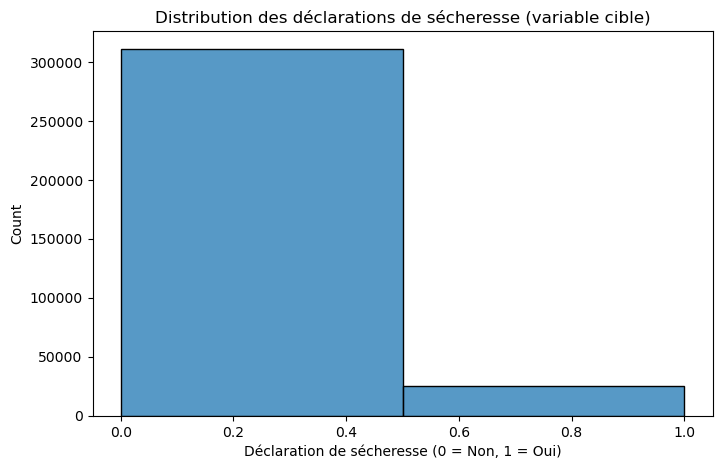

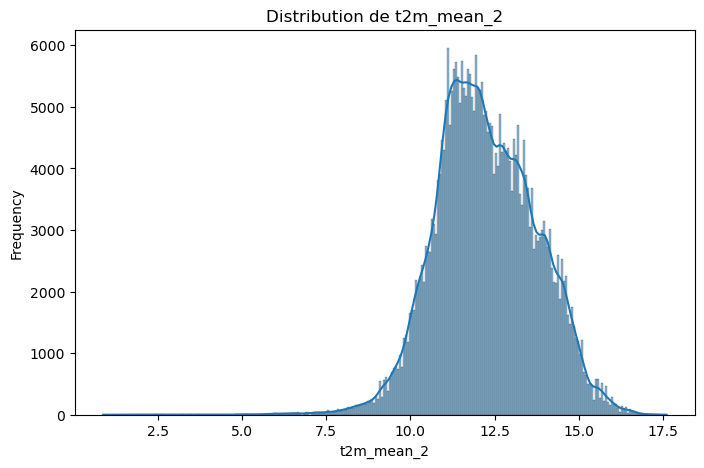

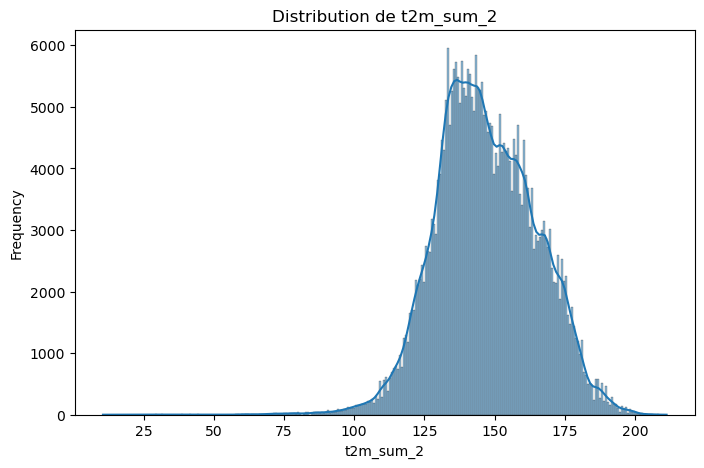

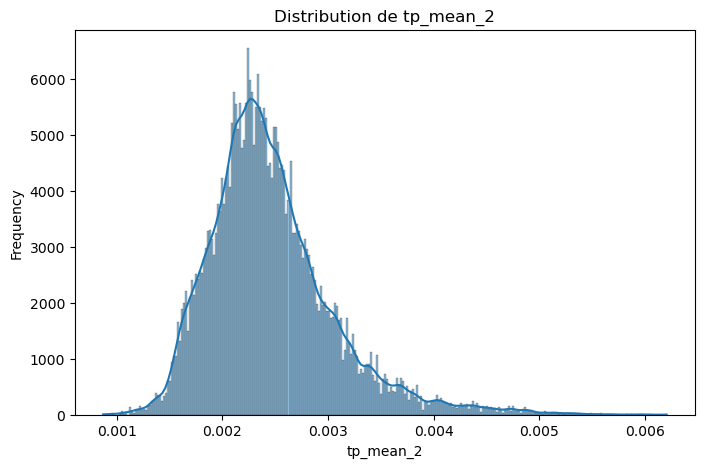

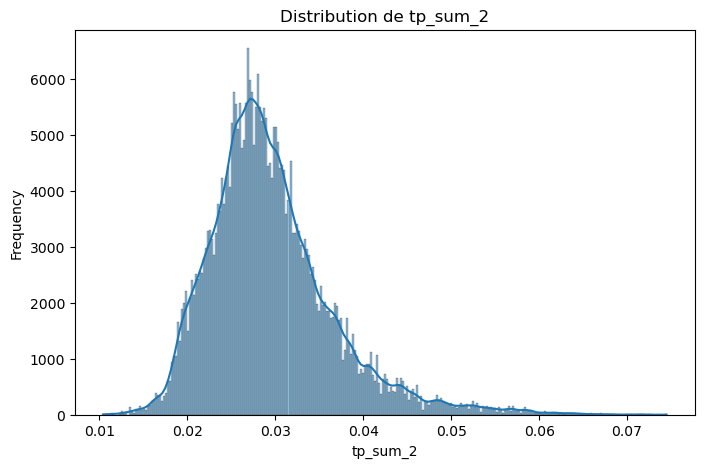

[I 2024-11-03 02:48:02,311] A new study created in memory with name: no-name-238219ea-c454-4040-ade0-4e266ba23991


Shape de l'ensemble d'entraînement pour l'année 2011 : (159150, 150)
Shape de l'ensemble de test pour l'année 2011 : (18479, 150)


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2024-11-03 02:48:02,954] Trial 0 finished with value: 0.22032693674484718 and parameters: {'n_estimators': 157, 'max_depth': 7, 'learning_rate': 0.2121511058904774, 'subsample': 0.7962179381784475, 'colsample_bytree': 0.8504942297791402}. Best is trial 0 with value: 0.22032693674484718.
[I 2024-11-03 02:48:03,490] Trial 1 finished with value: 0.35523020612598727 and parameters: {'n_estimators': 93, 'max_depth': 7, 'learning_rate': 0.00136606563907247, 'subsample': 0.6073045186350436, 'colsample_bytree': 0.9194180826240863}. Best is trial 1 with value: 0.35523020612598727.
[I 2024-11-03 02:48:03,773] Trial 2 finished with value: 0.27285678370904215 and parameters: {'n_estimators': 59, 'max_depth': 10, 'learning_rate': 0.273763591318974, 'subsample': 0.7374771103546423, 'colsample_bytree': 0.9732669756697218}. Best is trial 1 with value: 0.35523020612598727.
[I 2024-11-03 02:48:03,967] Trial 3 finished with value: 0.2888154111558367 and parameters: {'n_estimators': 50, 'max_depth': 3,

[I 2024-11-03 02:48:20,111] A new study created in memory with name: no-name-c33c38de-df9a-4815-b2da-6955f381863e


...

[I 2024-11-03 02:51:31,716] A new study created in memory with name: no-name-95f99743-6138-4d73-b421-b778c9ef39f5


Best threshold for year 2019: 0.5000000000000001
Shape de l'ensemble d'entraînement pour l'année 2020 : (161138, 150)
Shape de l'ensemble de test pour l'année 2020 : (15854, 150)


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2024-11-03 02:51:32,646] Trial 0 finished with value: 0.35171458825445956 and parameters: {'n_estimators': 165, 'max_depth': 7, 'learning_rate': 0.01090265970426624, 'subsample': 0.6170834575418723, 'colsample_bytree': 0.5627767902965871}. Best is trial 0 with value: 0.35171458825445956.
[I 2024-11-03 02:51:33,363] Trial 1 finished with value: 0.3329801725442712 and parameters: {'n_estimators': 244, 'max_depth': 4, 'learning_rate': 0.009686258939620716, 'subsample': 0.7676255309141808, 'colsample_bytree': 0.7611668074223035}. Best is trial 0 with value: 0.35171458825445956.
[I 2024-11-03 02:51:33,929] Trial 2 finished with value: 0.3269594452616096 and parameters: {'n_estimators': 118, 'max_depth': 9, 'learning_rate': 0.003156784550738955, 'subsample': 0.9902648589511671, 'colsample_bytree': 0.839959349932472}. Best is trial 0 with value: 0.35171458825445956.
[I 2024-11-03 02:51:34,202] Trial 3 finished with value: 0.2814092140921409 and parameters: {'n_estimators': 69, 'max_depth':

['lightgbm_model_20241103_024802.pkl']

In [33]:
# Prédiction des déclarations d'urgence de sécheresse pour les communes françaises
# Implementation utilisant un modèle LightGBM avec validation croissante, ajustement des hyperparamètres par Optuna, et optimisation du seuil de précision.

# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import recall_score, precision_score, precision_recall_curve, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from lightgbm import LGBMClassifier
import optuna
import datetime
import warnings
warnings.filterwarnings("ignore")

# Étape 1 : Charger le jeu de données (Supposons que le jeu de données soit en format CSV)
# df = pd.read_csv('french_communes_weather.csv')

# Étape 2 : Prétraitement des données
# Créer une copie du jeu de données d'origine pour travailler dessus
# Filtrer les données pour n'utiliser que les années entre 2000 et 2020

## Créer une copie du jeu de données pour préservation des données originales
# Cela permet de garantir que les données d'origine restent intactes.
df_copy = df[(df['year_1'] >= 2000) & (df['year_1'] <= 2020)].copy()

# Renommer 'Code Département_1' en 'Code_Departement_1' pour éviter les problèmes d'espaces
if 'Code Département_1' in df_copy.columns:
    df_copy.rename(columns={'Code Département_1': 'Code_Departement_1'}, inplace=True)

# Gérer les caractéristiques catégoriques avec OneHotEncoder
## Encoder "Code_Departement_1" s'il existe dans le jeu de données
if 'Code_Departement_1' in df_copy.columns:
    onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_departments = onehot_encoder.fit_transform(df_copy[['Code_Departement_1']])
    department_encoded_df = pd.DataFrame(encoded_departments, columns=onehot_encoder.get_feature_names_out(['Code_Departement_1']))

    # Réinitialiser les index pour garantir une bonne concaténation
    df_copy = df_copy.reset_index(drop=True)
    department_encoded_df = department_encoded_df.reset_index(drop=True)

    # Ajouter les colonnes encodées au jeu de données original et supprimer la colonne d'origine
    df_copy = pd.concat([df_copy.drop(columns=['Code_Departement_1']), department_encoded_df], axis=1)
else:
    print("La colonne 'Code_Departement_1' n'a pas été trouvée dans le jeu de données. Veuillez vérifier le nom de la colonne.")

# Étape 3 : Analyse exploratoire des données (EDA)
# Comprendre la distribution de la variable cible

def plot_target_variable_distribution():
    plt.figure(figsize=(8, 5))
    sns.histplot(df_copy['decision_1'], kde=False, bins=2)
    plt.title('Distribution des déclarations de sécheresse (variable cible)')
    plt.xlabel('Déclaration de sécheresse (0 = Non, 1 = Oui)')
    plt.ylabel('Count')
    plt.show()

# Afficher la distribution de la variable cible
plot_target_variable_distribution()

# Visualisation exploratoire - Distribution des caractéristiques de température et de précipitations
# Colonnes sélectionnées pour la température et les précipitations
weather_columns = ['t2m_mean_2', 't2m_sum_2', 'tp_mean_2', 'tp_sum_2']

def plot_feature_distributions(columns):
    for col in columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df_copy[col], kde=True)
        plt.title(f'Distribution de {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

# Afficher la distribution des caractéristiques
plot_feature_distributions(weather_columns)

# Étape 4 : Séparation des données - Prise en compte temporelle
# Trier les données par année pour respecter l'ordre temporel
df_copy = df_copy.sort_values(by='year_1')

# Créer une DataFrame pour stocker les prédictions de chaque cycle
all_predictions_df = pd.DataFrame()

# Variable pour sauvegarder le rapport de classification
current_time = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
classification_report_filename = f"classification_report_lightgbm_{current_time}.txt"

with open(classification_report_filename, 'w') as report_file:
    report_file.write("Rapport de classification pour chaque cycle d'entraînement:\n\n")

    # Étape 5 : Boucle sur chaque année de test de 2011 à 2020
    for test_year in range(2011, 2021):
        # Diviser le jeu de données en ensembles d'entraînment et de test basés sur l'année courante
        train = df_copy[df_copy['year_1'] < test_year]
        test = df_copy[df_copy['year_1'] == test_year]

        # Donner plus de poids aux 3 dernières années des données d'entraînement
        sample_weights = np.ones(len(train))
        recent_years = [test_year - 1, test_year - 2, test_year - 3]
        sample_weights[train['year_1'].isin(recent_years)] *= 2

        # Limiter le nombre d'années à 10 pour l'entraînement (fenêtre roulante)
        train = train[train['year_1'] >= max(2000, test_year - 10)]
        sample_weights = sample_weights[-len(train):]  # Ajuster les poids

        # Afficher la forme des ensembles d'entraînment et de test
        print(f"Shape de l'ensemble d'entraînement pour l'année {test_year} :", train.shape)
        print(f"Shape de l'ensemble de test pour l'année {test_year} :", test.shape)

        # Étape 6 : Définir les caractéristiques et la variable cible
        target = 'decision_1'
        weather_features = [col for col in df_copy.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]

        # Inclure les colonnes encodées si applicable
        all_features = list(department_encoded_df.columns) + weather_features if 'Code_Departement_1' in df.columns else weather_features

        # Ajouter 'applied_1' comme une caractéristique catégorique sans encodage si elle existe
        if 'applied_1' in df_copy.columns:
            all_features.append('applied_1')

        # Diviser les données en variables de caractéristiques et cible
        X_train = train[all_features]
        y_train = train[target]
        X_test = test[all_features]
        y_test = test[target]

        # Étape 7 : Construction du modèle LightGBM et optimisation des hyperparamètres avec Optuna
        # Créer le modèle de base LightGBM
        model = LGBMClassifier(random_state=42, class_weight='balanced', verbosity=-1)

        # Définir une fonction objective pour l'optimisation avec Optuna
        def objective(trial):
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
                'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0)
            }
            model.set_params(**param)
            model.fit(X_train, y_train, sample_weight=sample_weights)
            y_pred = model.predict_proba(X_test)[:, 1]
            y_pred_binary = (y_pred > 0.5).astype(int)
            f1 = f1_score(y_test, y_pred_binary, pos_label=1)
            return f1

        # Lancer l'optimisation d'Optuna pour trouver les meilleurs hyperparamètres
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=30, timeout=300, show_progress_bar=True)  # Limiter à 30 essais et 5 minutes par cycle

        # Récupérer les meilleurs hyperparamètres et mettre à jour le modèle
        best_params = study.best_params
        model.set_params(**best_params)
        model.fit(X_train, y_train, sample_weight=sample_weights)

        # Étape 8 : Ajustement du seuil pour améliorer la précision
        y_pred_probs = model.predict_proba(X_test)[:, 1]  # Probabilités pour la classe positive ("Drought")

        best_threshold = 0.5  # Initialiser le seuil par défaut
        best_precision = 0
        best_f1 = 0

        for threshold in np.arange(0.1, 1.0, 0.05):
            y_pred_adjusted = (y_pred_probs > threshold).astype(int)
            precision = precision_score(y_test, y_pred_adjusted)
            recall = recall_score(y_test, y_pred_adjusted)
            f1 = f1_score(y_test, y_pred_adjusted)

            # Sélectionner le seuil avec la meilleure précision et un rappel acceptable
            if precision > best_precision and recall > 0.5:
                best_threshold = threshold
                best_precision = precision
                best_f1 = f1

        # Faire les prédictions finales avec le seuil optimal
        y_pred_final = (y_pred_probs > best_threshold).astype(int)

        # Calculer et imprimer les métriques finales
        print(f"Best threshold for year {test_year}: {best_threshold}")

        report = classification_report(y_test, y_pred_final, target_names=['No Drought', 'Drought'], zero_division=1)
        
        # Sauvegarder les prédictions dans la DataFrame centralisée
        predictions = pd.DataFrame({
            'insee_1': test['insee_1'],
            'year_test': test_year,
            'predicted_drought': y_pred_final
        })
        all_predictions_df = pd.concat([all_predictions_df, predictions], axis=0)

        # Étape 9 : Évaluation du modèle
        # Calculer les métriques d'évaluation pour le modèle
        recall = recall_score(y_test, y_pred_final, pos_label=1)
        f1 = f1_score(y_test, y_pred_final, pos_label=1)
        roc_auc = roc_auc_score(y_test, y_pred_probs, average='weighted')

        # Sauvegarder le rapport de classification pour chaque année de test
        report_file.write(f"Année de test : {test_year}\n")
        report_file.write(f"Meilleurs hyperparamètres : {best_params}\n")
        report_file.write(f"Meilleur seuil : {best_threshold}\n")
        report_file.write(f"{report}\n\n")

# Sauvegarder la DataFrame de toutes les prédictions dans un fichier CSV
predictions_filename = f"all_predictions_lightgbm_{current_time}.csv"
all_predictions_df.to_csv(predictions_filename, index=False)

# Sauvegarder le modèle du dernier cycle avec date et heure
model_filename = f"lightgbm_model_{current_time}.pkl"
import joblib
joblib.dump(model, model_filename)

# Fin du Notebook


In [34]:
all_predictions_df

,insee_1,year_test,predicted_drought
187122,60139,2011,1
187121,60127,2011,0
187120,60117,2011,0
187119,60107,2011,1
187118,60106,2011,0
...,...,...,...
325352,33275,2020,0
325353,33276,2020,0
325354,33277,2020,0
325356,33279,2020,0


In [35]:

# Merge dataframes
merged_df = pd.merge(all_predictions_df, df, how='left', left_on=['insee_1', 'year_test'], right_on=['insee_1', 'year_1'])

# Select relevant columns
result = merged_df[['insee_1', 'year_test', 'predicted_drought', 'latitude_1', 'longitude_1', 'decision_1']]

print(result)

       insee_1  year_test  predicted_drought  latitude_1  longitude_1  \
0        60139       2011                  1   49.171810     2.246570   
1        60139       2011                  1   49.171810     2.246570   
2        60139       2011                  1   49.171810     2.246570   
3        60127       2011                  0   49.602551     2.800983   
4        60117       2011                  0   49.631424     2.980567   
...        ...        ...                ...         ...          ...   
169359   33275       2020                  0   44.707392    -0.168196   
169360   33276       2020                  0   44.402595    -0.059264   
169361   33277       2020                  0   44.769703     0.101173   
169362   33279       2020                  0   44.503806    -0.250078   
169363   95678       2020                  1   49.070289     2.239509   

        decision_1  
0                0  
1                0  
2                1  
3                0  
4                0

In [36]:
# Save the dataframe to a CSV file
#result.to_csv('merged_df.csv', index=False)
